<a href="https://colab.research.google.com/github/MonjokT/Predicting-Bridge-Structural-Health-and-Failure-Risk/blob/main/NBI_Bridge_ML__(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏗️ Predicting Bridge Structural Health & Failure Risk
### A Supervised Machine Learning Project | National Bridge Inventory 2023

---

## 📌 Project Overview
Every day, millions of people cross bridges without knowing whether the structure
beneath them is quietly deteriorating. In the United States alone, over 620,000
public bridges are inspected annually, generating one of the most comprehensive
infrastructure datasets in the world. Yet despite this data, maintenance decisions
are still largely reactive — bridges approach failure before anyone predicted it.

This project uses that inspection data to build a supervised machine learning pipeline
that predicts the structural condition of a bridge based on its physical and operational
characteristics. Specifically, we predict **`LOWEST_RATING`** — the minimum condition
score recorded across a bridge's inspected components — and use that to flag bridges
approaching critical failure thresholds.

We build and compare **six regression algorithms**, progressing from a simple baseline
to regularised models, and follow the complete data science workflow:

> Data Loading → Cleaning → EDA → Feature Engineering → Modelling → Evaluation → At-Risk Report

---

## 🏛️ About the Organisation
The **Federal Highway Administration (FHWA)** is a division of the U.S. Department
of Transportation responsible for overseeing the condition and safety of the nation's
highway infrastructure. Its **National Bridge Inspection Program** mandates that every
public bridge be physically inspected at least once every 24 months.

Every inspection produces a record in the **National Bridge Inventory (NBI)** — a
publicly available dataset covering structural condition, traffic load, material type,
geometry, load ratings and more for all 620,000+ bridges across the country.

---

## 👷 My Role
**Job Title:** Junior Machine Learning Engineer, Infrastructure Analytics
**Team:** Office of Infrastructure Data & Analytics, FHWA

As the Junior ML Engineer on this project, I am responsible for:
- Acquiring, cleaning and understanding the raw NBI inspection data
- Conducting exploratory data analysis to surface patterns in bridge deterioration
- Building and evaluating a suite of regression models to predict structural condition
- Identifying the features that most strongly drive structural deterioration
- Producing an actionable at-risk bridge report for use by state DOT policy teams

---

## 🗂️ About the Dataset
| Field | Detail |
|-------|--------|
| **Source** | Federal Highway Administration — National Bridge Inventory |
| **Year** | 2023 |
| **Download** | https://www.fhwa.dot.gov/bridge/nbi/ascii2023.cfm |
| **Format** | Comma-separated `.txt` file with single-quote text qualifier |
| **Total Records** | 621,581 bridge inspection records |
| **Total Columns** | 123 |

> **Note:** The NBI dataset contains two distinct structure types — regular highway
> bridges and culvert bridges (drainage pipes under roads). These have fundamentally
> different components. We separate them during cleaning and focus on highway bridges only.

---

## 📋 Columns Selected for This Project
Out of 123 available columns, we selected 16 that are relevant to predicting structural condition:

| Column | Description |
|--------|-------------|
| `STATE_CODE_001` | FIPS code identifying the US state the bridge is located in |
| `STRUCTURE_NUMBER_008` | Unique bridge identifier — like a passport number |
| `YEAR_BUILT_027` | Year the bridge was originally constructed |
| `ADT_029` | Average Daily Traffic — vehicles crossing per day |
| `MAIN_UNIT_SPANS_045` | Number of spans in the main structural unit |
| `STRUCTURE_LEN_MT_049` | Total length of the bridge structure in metres |
| `DECK_COND_058` | Condition of the bridge deck — surface cars drive on (0–9) |
| `SUPERSTRUCTURE_COND_059` | Condition of structural elements above the deck (0–9) |
| `SUBSTRUCTURE_COND_060` | Condition of elements below the deck — piers, abutments (0–9) |
| `CULVERT_COND_062` | Condition rating for culvert-type bridges (0–9) |
| `OPERATING_RATING_064` | Maximum load the bridge can safely carry under normal conditions |
| `INVENTORY_RATING_066` | Maximum load permitted for routine traffic use |
| `YEAR_RECONSTRUCTED_106` | Year of most recent major reconstruction (blank if never) |
| `PERCENT_ADT_TRUCK_109` | Percentage of daily traffic that is trucks |
| `BRIDGE_CONDITION` | FHWA overall text rating — Good, Fair or Poor |
| `LOWEST_RATING` | ⭐ **Target Variable** — minimum condition score across all components (0–9) |

---

## 🎯 Target Variable: `LOWEST_RATING`
A bridge is only as strong as its weakest component. This single number captures
the most critical structural risk signal in the dataset.

| Score | Meaning |
|-------|---------|
| 9 | Excellent |
| 8 | Very Good |
| 7 | Good |
| 6 | Satisfactory |
| 5 | Fair |
| 4 | Poor |
| 3 | Serious |
| 2 | Critical |
| 1 | Imminent Failure |
| 0 | Failed |

---

## ⚠️ Important Note on Feature Selection
`DECK_COND_058`, `SUPERSTRUCTURE_COND_059` and `SUBSTRUCTURE_COND_060` are the
**components** that define `LOWEST_RATING` — it is literally the minimum of those
three values. Including them as model features would be **data leakage**: the model
would trivially learn the relationship and produce artificially perfect scores, but
would not have learned anything useful.

We therefore build our models using only **physical and operational features** —
bridge age, traffic volume, load capacity, structure geometry — that a real
infrastructure analyst would use to forecast condition *without* having the
inspection scores already in hand.

---

## 🔬 Methodology
1. **Data Loading** — Mount Google Drive, load selected columns from the NBI file
2. **Data Cleaning** — Fix data types, remove invalid entries, handle placeholders
3. **EDA** — Visualise distributions, correlations and deterioration patterns
4. **Feature Engineering** — Create `BRIDGE_AGE`, `YEARS_SINCE_RENO`, `LOAD_RATIO`, `TRAFFIC_AGE`
5. **Model Building** — Six algorithms: Simple LR → Multiple LR → Polynomial → Ridge → Lasso → ElasticNet
6. **Evaluation** — Compare all six models on R², MAE and RMSE
7. **At-Risk Report** — Ranked list of bridges predicted to be in Poor or worse condition


In [ ]:
# Standard Data Libraries
import pandas as pd          # DataFrames — the backbone of all data manipulation
import numpy as np            # Numerical operations and array handling

# Visualisation
import matplotlib.pyplot as plt   # Base plotting library
import seaborn as sns             # Higher-level statistical visualisations built on matplotlib

# Machine Learning
from sklearn.model_selection import train_test_split          # Split data into train and test sets
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet  # Our six model types
from sklearn.preprocessing import PolynomialFeatures, StandardScaler         # Feature transforms
from sklearn.pipeline import Pipeline                                          # Chain steps cleanly
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Evaluation metrics

# Utilities
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical warnings to keep output clean

# Display Settings
pd.set_option('display.max_columns', 50)               # Show up to 50 columns at once
pd.set_option('display.float_format', '{:.2f}'.format) # Round all floats to 2 decimal places
sns.set_theme(style='whitegrid', palette='muted')      # Clean chart background
plt.rcParams['figure.figsize'] = [12, 5]               # Default chart size: 12 wide × 5 tall

print('✅ All libraries loaded successfully.')


✅ All libraries loaded successfully.


In [ ]:
# Because the file was to large and could not load due to poor connection
#I loaded the NBI_text file into google drive and sourced it from there
import os    # This module lets us interact with the file system — browse folders, check paths etc.

for root, dirs, files in os.walk('/content/drive/MyDrive'):   # start searching from the root of your Drive
    for file in files:
        if 'nbi' in file.lower():                              # check if the filename contains 'nbi' (lowercase to catch any variation)
            print(os.path.join(root, file))

#for reference i am using the first file path because that is the dataset itself

/content/drive/MyDrive/Colab Notebooks/nbi_2023.txt
/content/drive/MyDrive/Colab Notebooks/NBI_data.ipynb
/content/drive/MyDrive/Colab Notebooks/Copy of NBI_Bridge_ML (1).ipynb
/content/drive/MyDrive/Colab Notebooks/NBI_Bridge_ML_ (1).ipynb


In [ ]:
# Step 1: Mount Google Drive
# copy the NBI file path that lives in your Google Drive.But first,there is a need to mount the drive first
# so Colab can access files stored there as if they were on a local file system.
from google.colab import drive
drive.mount('/content/drive')  # After running this, click the link and authorise access

# Step 2: Set the file path
# Update this path if your file is stored in a sub-folder inside MyDrive
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/nbi_2023.txt'


#Step 3: Identify which columns you will be needing for your analysis and the total number of columns present in the dataset
df_cols = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/nbi_2023.txt',#The file part
    sep=',',
    quotechar="'",
    low_memory=False,
    nrows=0
)

df_cols.info()#This tells us there a bit about the dataset and the total number of columns present.
#from the first column 'STATE_CODE_001' to the last one' Deck_Area'
#It also uses 132byte





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 0 entries
Columns: 123 entries, STATE_CODE_001 to DECK_AREA
dtypes: int64(123)
memory usage: 132.0 bytes


In [ ]:
#The NBI File has 123 columns total. We only need to load specific columns for the scope of this project.
#Step 4: Print ALL 123 Column Names From the Raw File
df_cols = pd.read_csv(
    '/content/drive/MyDrive/Colab Notebooks/nbi_2023.txt',
    sep=',',#Tells Pandas that a comma separates each piece of data.
    quotechar="'",#Tells Pandas that if it sees a single quote, it should treat everything inside those quotes as a single block of text (ignoring any commas inside).
    low_memory=False,
    nrows=0
)

print(f'Total columns in file: {len(df_cols.columns)}')  # confirms total number of columns
print()

for i, col in enumerate(df_cols.columns):  # loop through every column name with a position counter
    print(f'{i:>3}  {col}')               # print the position number and column name neatly aligned

Total columns in file: 123

  0  STATE_CODE_001
  1  STRUCTURE_NUMBER_008
  2  RECORD_TYPE_005A
  3  ROUTE_PREFIX_005B
  4  SERVICE_LEVEL_005C
  5  ROUTE_NUMBER_005D
  6  DIRECTION_005E
  7  HIGHWAY_DISTRICT_002
  8  COUNTY_CODE_003
  9  PLACE_CODE_004
 10  FEATURES_DESC_006A
 11  CRITICAL_FACILITY_006B
 12  FACILITY_CARRIED_007
 13  LOCATION_009
 14  MIN_VERT_CLR_010
 15  KILOPOINT_011
 16  BASE_HWY_NETWORK_012
 17  LRS_INV_ROUTE_013A
 18  SUBROUTE_NO_013B
 19  LAT_016
 20  LONG_017
 21  DETOUR_KILOS_019
 22  TOLL_020
 23  MAINTENANCE_021
 24  OWNER_022
 25  FUNCTIONAL_CLASS_026
 26  YEAR_BUILT_027
 27  TRAFFIC_LANES_ON_028A
 28  TRAFFIC_LANES_UND_028B
 29  ADT_029
 30  YEAR_ADT_030
 31  DESIGN_LOAD_031
 32  APPR_WIDTH_MT_032
 33  MEDIAN_CODE_033
 34  DEGREES_SKEW_034
 35  STRUCTURE_FLARED_035
 36  RAILINGS_036A
 37  TRANSITIONS_036B
 38  APPR_RAIL_036C
 39  APPR_RAIL_END_036D
 40  HISTORY_037
 41  NAVIGATION_038
 42  NAV_VERT_CLR_MT_039
 43  NAV_HORR_CLR_MT_040
 44  OPEN_CLOSED_POSTE

In [ ]:
#  Step 5: Define the columns we want to load
# The full NBI file has 123 columns. We only load the 16 relevant to this project.
# Loading only what we need saves memory and speeds up the read significantly.
COLUMNS_TO_LOAD = [
    'STATE_CODE_001',           # FIPS code for the US state where the bridge is located
    'STRUCTURE_NUMBER_008',     # Unique ID for each bridge — like a bridge passport number
    'YEAR_BUILT_027',           # Year the bridge was originally constructed
    'ADT_029',                  # Average Daily Traffic — how many vehicles cross per day
    'MAIN_UNIT_SPANS_045',      # Number of spans (sections) in the main structural unit
    'STRUCTURE_LEN_MT_049',     # Total length of the bridge in metres
    'DECK_COND_058',            # Condition of the bridge deck (0–9) — the surface vehicles drive on
    'SUPERSTRUCTURE_COND_059',  # Condition of structural elements above the deck (0–9)
    'SUBSTRUCTURE_COND_060',    # Condition of elements below the deck — piers, abutments (0–9)
    'CULVERT_COND_062',         # Condition rating used only for culvert-type bridges (0–9)
    'OPERATING_RATING_064',     # Maximum load the bridge can safely carry under normal conditions
    'INVENTORY_RATING_066',     # Maximum load permitted for routine daily traffic
    'YEAR_RECONSTRUCTED_106',   # Year of the most recent major reconstruction (blank if never)
    'PERCENT_ADT_TRUCK_109',    # Percentage of daily traffic that is trucks
    'BRIDGE_CONDITION',         # FHWA text rating: Good / Fair / Poor
    'LOWEST_RATING',            # ⭐ TARGET — minimum condition score across all components (0–9)
]

# Step 4: Load the file
print('Loading NBI data from Google Drive...')
print('This may take 30–90 seconds depending on your connection.')
print()

df_raw = pd.read_csv(
    FILE_PATH,
    sep=',',                                          # Values are comma-separated
    quotechar="'",                                    # Text fields are wrapped in single quotes
    low_memory=False,                                 # Prevents pandas from guessing dtypes incorrectly
    usecols=lambda col: col in COLUMNS_TO_LOAD        # Only read the 16 columns listed above
)

#Step 5: Confirm the load
print(f'✅ Loaded {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns.')
print(f'   Memory used: {df_raw.memory_usage(deep=True).sum() / 1024**2:.1f} MB')
print()

# Quick visual check — the first 10 rows
print('=== FIRST 10 ROWS ===')
df_raw.head(10)


Loading NBI data from Google Drive...
This may take 30–90 seconds depending on your connection.

✅ Loaded 621,581 rows and 16 columns.
   Memory used: 233.6 MB

=== FIRST 10 ROWS ===


,STATE_CODE_001,STRUCTURE_NUMBER_008,YEAR_BUILT_027,ADT_029,MAIN_UNIT_SPANS_045,STRUCTURE_LEN_MT_049,DECK_COND_058,SUPERSTRUCTURE_COND_059,SUBSTRUCTURE_COND_060,CULVERT_COND_062,OPERATING_RATING_064,INVENTORY_RATING_066,YEAR_RECONSTRUCTED_106,PERCENT_ADT_TRUCK_109,BRIDGE_CONDITION,LOWEST_RATING
0,1,00000000000S702,1999,50,1,15.00,7,5,7,N,44.50,32.70,0.00,1.00,F,5
1,1,00000000000S703,2002,159,1,13.60,7,6,7,N,84.80,35.10,0.00,1.00,F,6
2,1,0000000000M0022,1942,375,3,43.00,5,5,6,N,32.70,22.50,0.00,35.00,F,5
3,1,000000883039900,1974,205,5,65.50,7,7,7,N,44.20,26.60,0.00,5.00,G,7
4,1,000001014002450,1937,5358,2,1981.20,5,6,5,N,40.00,23.90,1962.00,10.00,F,5
5,1,000001331700710,1924,2841,8,1512.40,5,5,5,N,58.40,35.00,1958.00,8.00,F,5
6,1,000002,1898,400,1,51.80,6,4,5,N,0.00,0.00,0.00,1.00,P,4
7,1,000004,1900,150,1,48.20,4,4,4,N,0.00,0.00,0.00,1.00,P,4
8,1,000004504800350,1939,191,1,19.20,7,7,7,N,47.70,28.80,0.00,5.00,G,7
9,1,000005,1900,15,2,15.50,5,4,4,N,4.50,2.70,0.00,0.00,P,4


## 📖 Understanding the Data: The Story of a Single Bridge

Before we dive into numbers, it helps to understand what a single row in this
dataset actually represents in the real world.

Every entry in the NBI begins with a **geographic and identity footprint**. A bridge
coded `01` is located in **Alabama**, and its unique **Structure Number** acts as a
permanent identifier,allowing the government to track this specific asset across
decades of inspections, repairs and reconstructions.

The dataset then captures the **physical reality** of the bridge. A structure built
in **1999** with an Average Daily Traffic of **50 vehicles** is a quiet, rural crossing.
At **15 metres**, it is roughly the length of a standard school bus,modest in scale,
but still a critical link in the road network.

The **condition ratings** are where the real story lives. Each structural component,
the deck (the surface you drive on), the superstructure (the beams and girders above),
and the substructure (the piers and abutments below), receives an independent score
from **0 (Failed)** to **9 (Excellent)**.

In the logic of bridge safety, **the weakest component defines the safety status of
the entire structure**. If the deck and substructure score **7 (Good)** but the
superstructure has slipped to **5 (Fair)**, the bridge's overall `LOWEST_RATING`
is **5**, and it is classified as **Fair condition** overall.

This is the number our models are trained to predict. Not from the inspection scores
themselves (that would be cheating,see the note in the Project Overview), but from
the physical characteristics of the bridge that a maintenance planner would have
access to *before* sending an inspector out: how old it is, how much traffic it carries,
how long it is, what load it was built to handle.


In [ ]:
# First honest look at the raw data as pandas loaded it.
df_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 621581 entries, 0 to 621580
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   STATE_CODE_001           621581 non-null  int64  
 1   STRUCTURE_NUMBER_008     621581 non-null  object 
 2   YEAR_BUILT_027           621581 non-null  int64  
 3   ADT_029                  621581 non-null  int64  
 4   MAIN_UNIT_SPANS_045      621581 non-null  int64  
 5   STRUCTURE_LEN_MT_049     621581 non-null  float64
 6   DECK_COND_058            621581 non-null  object 
 7   SUPERSTRUCTURE_COND_059  621581 non-null  object 
 8   SUBSTRUCTURE_COND_060    621581 non-null  object 
 9   CULVERT_COND_062         621581 non-null  object 
 10  OPERATING_RATING_064     620567 non-null  float64
 11  INVENTORY_RATING_066     620561 non-null  float64
 12  YEAR_RECONSTRUCTED_106   546506 non-null  float64
 13  PERCENT_ADT_TRUCK_109    592978 non-null  float64
 14  BRID

Here we can see that Column 10,11,14 and 15,have some missing values in them because they do not align with the total entry (i.e 621581). While column 6,7,8,and 9 are classified as object(Text)types which should not be true because if you look at the first row of 'df_raw.head(15),' you will see some are in numbers(int) or/and with a string like the letter 'N'.

Note, If a bridge doesn't have a deck (like a culvert), the inspector puts an 'N' (Not Applicable). Pandas sees one 'N' and decides the entire column is text.To fix this, We need to convert these to numbers and decide what to do with the 'N's.

In [ ]:
# Full Raw Data Profile

print('=' * 55)
print('  RAW DATA OVERVIEW')
print('=' * 55)

# Shape — how many rows and columns did we actually load?
print(f'\nRows    : {df_raw.shape[0]:,}')    # total number of bridge records
print(f'Columns : {df_raw.shape[1]}')         # should be 16

# Missing Values
print('\n=== MISSING VALUES ===')
missing = df_raw.isnull().sum()                              # count nulls in each column
missing_pct = (missing / len(df_raw) * 100).round(2)        # express as a percentage
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])           # only show columns that have gaps

# Basic Statistics
print('\n=== BASIC STATISTICS (numeric columns) ===')
print(df_raw.describe())    # min, max, mean, std for every numeric column at once

#Target Variable Check
print('\n=== TARGET VARIABLE: LOWEST_RATING ===')
print(f"Missing values : {df_raw['LOWEST_RATING'].isnull().sum()}")
print(f"Unique values  : {sorted(df_raw['LOWEST_RATING'].dropna().unique())}")
print(f"Min: {df_raw['LOWEST_RATING'].min()}  |  Max: {df_raw['LOWEST_RATING'].max()}  |  Mean: {df_raw['LOWEST_RATING'].mean():.2f}")

#Bridge Condition (text label)
print('\n=== BRIDGE_CONDITION (text category) ===')
print(df_raw['BRIDGE_CONDITION'].value_counts(dropna=False))  # Good / Fair / Poor counts + any nulls


  RAW DATA OVERVIEW

Rows    : 621,581
Columns : 16

=== MISSING VALUES ===
                        Missing Count  Missing %
YEAR_RECONSTRUCTED_106          75075      12.08
PERCENT_ADT_TRUCK_109           28603       4.60
OPERATING_RATING_064             1014       0.16
INVENTORY_RATING_066             1020       0.16

=== BASIC STATISTICS (numeric columns) ===
       STATE_CODE_001  YEAR_BUILT_027   ADT_029  MAIN_UNIT_SPANS_045  \
count       621581.00       621581.00 621581.00            621581.00   
mean            30.02         1976.67   7865.72                 2.79   
std             15.37           26.57  21106.63                 6.18   
min              1.00         1697.00      0.00                 0.00   
25%             18.00         1960.00    121.00                 1.00   
50%             29.00         1978.00    945.00                 2.00   
75%             42.00         1998.00   6300.00                 3.00   
max             78.00         2023.00 999999.00            

## 🧹 Data Cleaning

Before building any model, we must clean the raw data. The overview above reveals
several problems that would corrupt our analysis if left unfixed. This section
addresses each one systematically.

---

### Problems Found in the Raw Data

**1. Condition columns are stored as text, not numbers**
Columns like `DECK_COND_058` and `SUPERSTRUCTURE_COND_059` should contain numeric
ratings from 0–9. However, the NBI uses the letter `N` to mean "Not Applicable" for
bridges where that component does not exist (e.g., a bridge with no culvert gets `N`
in the culvert column). The moment pandas sees even one letter, it treats the entire
column as text. We convert these back to numbers — `N` becomes `NaN` (a proper missing value).

**2. `ADT_029` contains the placeholder value 999,999**
FHWA uses `999999` when the actual traffic count for a bridge is unknown. This is not
a real traffic figure — it would massively distort our model. We replace it with `NaN`.

**3. `YEAR_BUILT_027` contains values as early as 1697**
No public highway bridge from 1697 would still be in active service in a modern
inspection database. These are almost certainly data entry errors. We remove any
bridge with a year built before 1800.

**4. `YEAR_RECONSTRUCTED_106` contains zeros and future years**
Zero is not a real year. Values above 2024 are future years — also entry errors.
Both get replaced with `NaN` and handled properly in Feature Engineering.

**5. `MAIN_UNIT_SPANS_045` contains zero values**
A bridge must have at least one span by definition. Zero is a bad entry and gets removed.

**6. `LOWEST_RATING` must be between 0 and 9**
Any value outside this range is corrupt and gets removed.

**7. Load ratings have missing values**
`OPERATING_RATING_064` and `INVENTORY_RATING_066` have some missing entries.
We fill them with the median (middle value) of their respective columns.

---

### Our Approach
We always clean on a **copy** of `df_raw`, never the original. This means if we make
a mistake at any point, we can return to `df_raw` and start the cleaning step again
without having to reload the file from Google Drive.


In [ ]:
# Cleaning on a Copy without messing with the original file.
df = df_raw.copy()

print(f'Starting rows: {len(df):,}')
print()

# Fix 1: Convert condition columns from text to numbers
# These columns should hold ratings 0–9, but pandas read them as text because
# the NBI uses the letter 'N' for components that don't exist on a particular bridge.
# pd.to_numeric(..., errors='coerce') converts valid numbers and turns 'N' into NaN.

condition_cols = [
    'DECK_COND_058',            # deck condition rating
    'SUPERSTRUCTURE_COND_059',  # superstructure condition rating
    'SUBSTRUCTURE_COND_060',    # substructure condition rating
    'CULVERT_COND_062',         # culvert condition rating (only applies to culvert bridges)
]

for col in condition_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')   # convert; anything non-numeric becomes NaN
    print(f'Converted {col} → numeric  |  NaN values created: {df[col].isnull().sum():,}')

print()
print('✅ Condition columns converted to numeric.')


Starting rows: 621,581

Converted DECK_COND_058 → numeric  |  NaN values created: 151,653
Converted SUPERSTRUCTURE_COND_059 → numeric  |  NaN values created: 146,585
Converted SUBSTRUCTURE_COND_060 → numeric  |  NaN values created: 146,739
Converted CULVERT_COND_062 → numeric  |  NaN values created: 474,984

✅ Condition columns converted to numeric.


In [ ]:
# Fix 2: Remove bridges with implausibly old construction years
# Any bridge with YEAR_BUILT before 1800 is almost certainly a data entry error.
# This is because No active public highway bridge from the 1600s or 1700s would appear in a
# modern federal inspection database.

before = len(df)                             # record current row count before removal
df = df[df['YEAR_BUILT_027'] >= 1800]        # keep only bridges built 1800 or later
removed = before - len(df)                  # calculate how many rows were dropped

print(f'Removed {removed:,} rows where YEAR_BUILT_027 < 1800')
print(f'Rows remaining: {len(df):,}')


Removed 10 rows where YEAR_BUILT_027 < 1800
Rows remaining: 621,571


In [ ]:
# Fix 3: Remove bridges with zero spans
# A bridge must have at least 1 span by definition.
# Any record showing zero spans is a corrupt entry and must be removed.

before = len(df)
df = df[df['MAIN_UNIT_SPANS_045'] > 0]       # keep only bridges with 1 or more spans
print(f'Removed {before - len(df):,} rows where MAIN_UNIT_SPANS_045 = 0')

# Fix 4: Replace ADT placeholder value with NaN
# Note: the FHWA uses 999999 as a code for "traffic count unknown". It is not a real number.
# Why?Because carrying nearly 1 million vehicles per day, which would skew predictions.

adt_placeholders = (df['ADT_029'] == 999999).sum()           # count how many placeholders exist
df['ADT_029'] = df['ADT_029'].replace(999999, np.nan)        # replace with NaN (proper missing value)
print(f'Replaced {adt_placeholders:,} ADT_029 placeholder values (999999) with NaN')

print(f'\nRows remaining: {len(df):,}')


Removed 1,222 rows where MAIN_UNIT_SPANS_045 = 0
Replaced 1 ADT_029 placeholder values (999999) with NaN

Rows remaining: 620,349


In [ ]:
# Fix 5: Clean YEAR_RECONSTRUCTED_106
# Zero means the bridge was never reconstructed — zero is not a real year,
# so we replace it with NaN and handle it properly during feature engineering.
# Values above 2024 are future years — clearly entry errors — also set to NaN.

df['YEAR_RECONSTRUCTED_106'] = df['YEAR_RECONSTRUCTED_106'].replace(0, np.nan)
future_years = (df['YEAR_RECONSTRUCTED_106'] > 2024).sum()
df.loc[df['YEAR_RECONSTRUCTED_106'] > 2024, 'YEAR_RECONSTRUCTED_106'] = np.nan
print(f'Set {future_years:,} future reconstruction years to NaN')

#Fix 6: Remove rows where LOWEST_RATING is outside valid range
# Valid ratings are 0–9. Anything outside that range is corrupt data.

before = len(df)
df = df[(df['LOWEST_RATING'] >= 0) & (df['LOWEST_RATING'] <= 9)]
print(f'Removed {before - len(df):,} rows with LOWEST_RATING outside 0–9')

# ── Fix 7: Fill missing load ratings with the column median ───────────────────
# OPERATING_RATING and INVENTORY_RATING each have some missing values.
# The median is more robust than the mean here because load rating distributions
# tend to be skewed by a small number of very high-capacity bridges.

med_op  = df['OPERATING_RATING_064'].median()   # median of all non-null operating ratings
med_inv = df['INVENTORY_RATING_066'].median()   # median of all non-null inventory ratings

df['OPERATING_RATING_064'] = df['OPERATING_RATING_064'].fillna(med_op)
df['INVENTORY_RATING_066'] = df['INVENTORY_RATING_066'].fillna(med_inv)

print(f'Filled missing OPERATING_RATING_064 with median: {med_op:.1f}')
print(f'Filled missing INVENTORY_RATING_066 with median: {med_inv:.1f}')

#Fix 8: Fill missing truck % with column mean
avg_truck = df['PERCENT_ADT_TRUCK_109'].mean()
df['PERCENT_ADT_TRUCK_109'] = df['PERCENT_ADT_TRUCK_109'].fillna(avg_truck)
print(f'Filled missing PERCENT_ADT_TRUCK_109 with mean: {avg_truck:.1f}%')

print()
print(f'✅ Cleaning complete. Rows remaining: {len(df):,}')
print(f'   Total rows removed from raw data: {621581 - len(df):,}')


Set 5 future reconstruction years to NaN
Removed 0 rows with LOWEST_RATING outside 0–9
Filled missing OPERATING_RATING_064 with median: 53.5
Filled missing INVENTORY_RATING_066 with median: 32.7
Filled missing PERCENT_ADT_TRUCK_109 with mean: 8.3%

✅ Cleaning complete. Rows remaining: 620,349
   Total rows removed from raw data: 1,232


##  Separating Highway Bridges from Culverts

The NBI dataset contains two fundamentally different types of structures:

- **Highway Bridges**  traditional bridges with a deck, superstructure and substructure
- **Culverts** : drainage pipes built under roads, rated using a single `CULVERT_COND_062` score

These two types cannot be modelled together. A culvert has no deck or superstructure,
so those fields are always `NaN` for culverts, but that `NaN` means something completely
different than a missing value on a highway bridge. Mixing them would confuse any model.

We identify culverts as records where:
1. `CULVERT_COND_062` contains a valid numeric rating (i.e., it actually is a culvert), **OR**
2. All three primary structural component ratings (deck, superstructure, substructure)
   are `NaN` : meaning none of the bridge-specific components were inspected.

Everything else is a highway bridge.


In [ ]:
#Identify Bridges Culverts
# A record is a culvert if:
#   (a) it has a valid culvert condition rating, OR
#   (b) all three bridge-specific component ratings are missing

is_culvert = (
    df['CULVERT_COND_062'].notna()    # has a culvert rating → it's a culvert
    |
    (                                 # OR all three structural components are NaN
        df['DECK_COND_058'].isna() &
        df['SUPERSTRUCTURE_COND_059'].isna() &
        df['SUBSTRUCTURE_COND_060'].isna()
    )
)

# Create two separate DataFrames
df_culverts = df[is_culvert].copy()    # culvert records
df_bridges  = df[~is_culvert].copy()  # highway bridge records (tilde = NOT is_culvert)

print(f'Cleaned dataset total rows : {len(df):,}')
print(f'Highway bridges (df_bridges): {len(df_bridges):,}')
print(f'Culvert bridges (df_culverts): {len(df_culverts):,}')
print(f'Sum check: {len(df_bridges) + len(df_culverts):,} (should match total above)')
print()

# Quick visual check on each group
print('--- Sample Highway Bridges ---')
display(df_bridges.head(3))

print('--- Sample Culverts ---')
display(df_culverts.head(3))

# ── For the remainder of this notebook, we only work with df_bridges ──────────
print(f'\n✅ All modelling from this point forward uses df_bridges ({len(df_bridges):,} records).')


Cleaned dataset total rows : 620,349
Highway bridges (df_bridges): 474,880
Culvert bridges (df_culverts): 145,469
Sum check: 620,349 (should match total above)

--- Sample Highway Bridges ---


,STATE_CODE_001,STRUCTURE_NUMBER_008,YEAR_BUILT_027,ADT_029,MAIN_UNIT_SPANS_045,STRUCTURE_LEN_MT_049,DECK_COND_058,SUPERSTRUCTURE_COND_059,SUBSTRUCTURE_COND_060,CULVERT_COND_062,OPERATING_RATING_064,INVENTORY_RATING_066,YEAR_RECONSTRUCTED_106,PERCENT_ADT_TRUCK_109,BRIDGE_CONDITION,LOWEST_RATING
0,1,00000000000S702,1999,50.00,1,15.00,7.00,5.00,7.00,NaN,44.50,32.70,NaN,1.00,F,5
1,1,00000000000S703,2002,159.00,1,13.60,7.00,6.00,7.00,NaN,84.80,35.10,NaN,1.00,F,6
2,1,0000000000M0022,1942,375.00,3,43.00,5.00,5.00,6.00,NaN,32.70,22.50,NaN,35.00,F,5


--- Sample Culverts ---


,STATE_CODE_001,STRUCTURE_NUMBER_008,YEAR_BUILT_027,ADT_029,MAIN_UNIT_SPANS_045,STRUCTURE_LEN_MT_049,DECK_COND_058,SUPERSTRUCTURE_COND_059,SUBSTRUCTURE_COND_060,CULVERT_COND_062,OPERATING_RATING_064,INVENTORY_RATING_066,YEAR_RECONSTRUCTED_106,PERCENT_ADT_TRUCK_109,BRIDGE_CONDITION,LOWEST_RATING
13,1,00000BLN0BR0010,1974,250.00,2,6.40,NaN,NaN,NaN,6.00,37.30,28.80,NaN,1.00,F,6
16,1,000019,1900,250.00,2,14.60,NaN,NaN,NaN,5.00,35.70,28.80,NaN,1.00,F,5
23,1,000042,1910,11430.00,2,28.00,NaN,NaN,NaN,5.00,32.70,23.60,NaN,3.00,F,5



✅ All modelling from this point forward uses df_bridges (474,880 records).


## 📊 Exploratory Data Analysis (EDA)



In this section,We will examine:
1. The distribution of our target variable, `LOWEST_RATING`
2. The split between Good, Fair and Poor bridges
3. How structural condition relates to bridge age
4. How traffic load relates to structural condition and;
5. The correlation matrix in-which features are most related to our target.


In [ ]:
# The cleaned highway bridges dataset is Inspected before any visualisation.
# All numeric, no unexpected NaNs in key columns,are confirmed, and the row count should look reasonable.
print(f'Shape: {df_bridges.shape}')
print()
df_bridges.info()


Shape: (474880, 16)

<class 'pandas.core.frame.DataFrame'>
Index: 474880 entries, 0 to 621580
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   STATE_CODE_001           474880 non-null  int64  
 1   STRUCTURE_NUMBER_008     474880 non-null  object 
 2   YEAR_BUILT_027           474880 non-null  int64  
 3   ADT_029                  474879 non-null  float64
 4   MAIN_UNIT_SPANS_045      474880 non-null  int64  
 5   STRUCTURE_LEN_MT_049     474880 non-null  float64
 6   DECK_COND_058            469812 non-null  float64
 7   SUPERSTRUCTURE_COND_059  474865 non-null  float64
 8   SUBSTRUCTURE_COND_060    474712 non-null  float64
 9   CULVERT_COND_062         0 non-null       float64
 10  OPERATING_RATING_064     474880 non-null  float64
 11  INVENTORY_RATING_066     474880 non-null  float64
 12  YEAR_RECONSTRUCTED_106   76943 non-null   float64
 13  PERCENT_ADT_TRUCK_109    474880 non-null  f

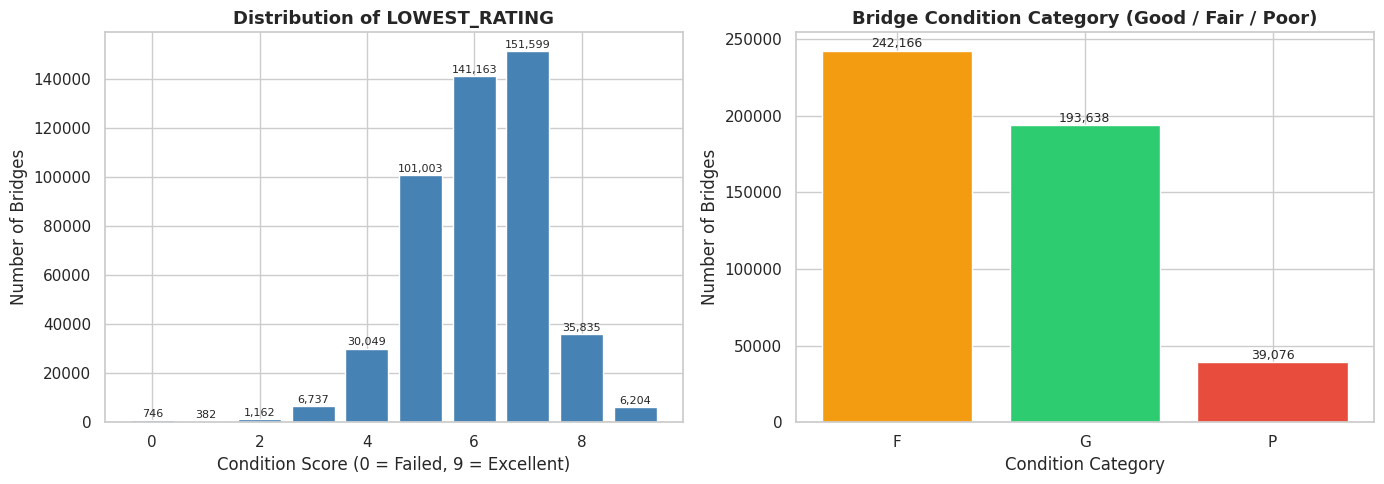


Condition breakdown:
  F: 242,166 bridges (51.0%)
  G: 193,638 bridges (40.8%)
  P: 39,076 bridges (8.2%)


In [ ]:
# Plot 1: Distribution of LOWEST_RATING
# This is the first plot we always make for a regression target:
# What values does it take? Is it spread evenly or skewed to one side?
# A heavily skewed target may need transformation before modelling.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))   # 1 row, 2 side-by-side charts

# Left chart: count bar for each rating value (0–9)
rating_counts = df_bridges['LOWEST_RATING'].value_counts().sort_index()
axes[0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of LOWEST_RATING', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Condition Score (0 = Failed, 9 = Excellent)')
axes[0].set_ylabel('Number of Bridges')
# Add the count as a label on top of each bar
for x, y in zip(rating_counts.index, rating_counts.values):
    axes[0].text(x, y + 500, f'{y:,}', ha='center', va='bottom', fontsize=8)

# Right chart: BRIDGE_CONDITION text categories (Good / Fair / Poor)
cond_counts = df_bridges['BRIDGE_CONDITION'].value_counts()
colours = {'G': '#2ecc71', 'F': '#f39c12', 'P': '#e74c3c', 'N': '#95a5a6'}
bar_colours = [colours.get(c, '#95a5a6') for c in cond_counts.index]
axes[1].bar(cond_counts.index, cond_counts.values, color=bar_colours, edgecolor='white')
axes[1].set_title('Bridge Condition Category (Good / Fair / Poor)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Condition Category')
axes[1].set_ylabel('Number of Bridges')
for x, y in zip(range(len(cond_counts)), cond_counts.values):
    axes[1].text(x, y + 500, f'{y:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()    # prevents charts from overlapping
plt.show()

# Print summary percentages
print('\nCondition breakdown:')
for cat, count in cond_counts.items():
    pct = count / len(df_bridges) * 100
    print(f'  {cat}: {count:,} bridges ({pct:.1f}%)')


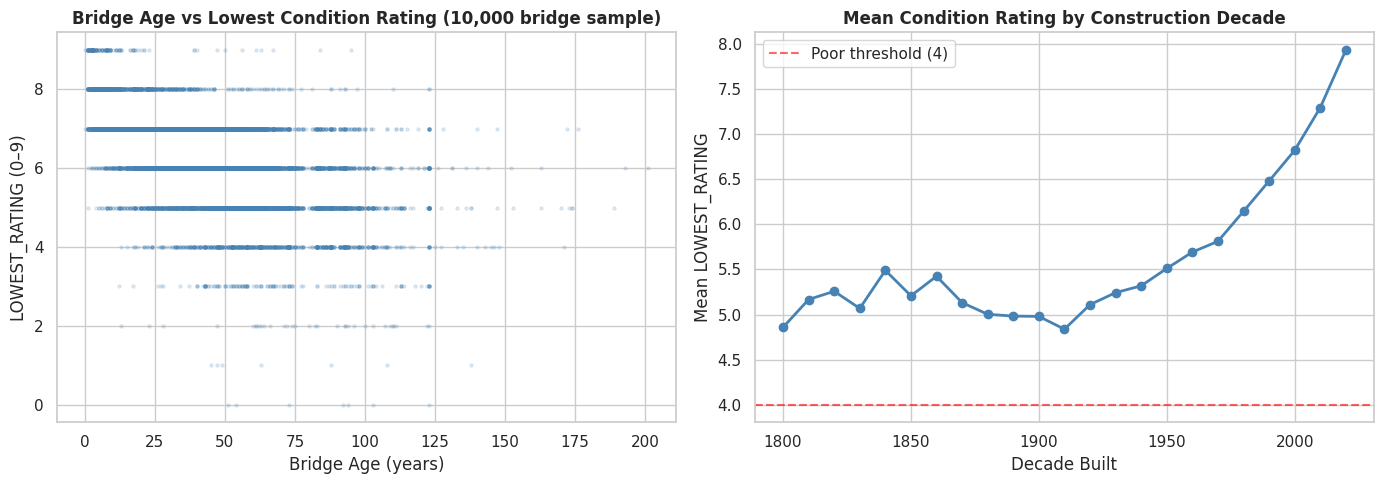

In [ ]:
# ── Plot 2: Bridge Age vs LOWEST_RATING ──────────────────────────────────────
# Our core intuition is: older bridges should be in worse condition.
# This plot tests that intuition before we build any model.
# We use a temporary age column here — we will formally engineer it in the next section.

temp_age = 2023 - df_bridges['YEAR_BUILT_027']   # bridge age in years (temporary, just for EDA)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter of individual bridges (sampled to avoid overplotting 400k points)
sample = df_bridges.sample(n=min(10000, len(df_bridges)), random_state=42)  # random 10,000 bridge sample
temp_sample_age = 2023 - sample['YEAR_BUILT_027']
axes[0].scatter(temp_sample_age, sample['LOWEST_RATING'],
                alpha=0.15,          # low opacity so we can see density
                s=5,                 # small dot size
                color='steelblue')
axes[0].set_title('Bridge Age vs Lowest Condition Rating (10,000 bridge sample)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Bridge Age (years)')
axes[0].set_ylabel('LOWEST_RATING (0–9)')

# Right: mean rating by decade of construction — cleaner trend line
df_bridges_temp = df_bridges.copy()
df_bridges_temp['DECADE_BUILT'] = (df_bridges_temp['YEAR_BUILT_027'] // 10) * 10  # round year down to decade
decade_avg = df_bridges_temp.groupby('DECADE_BUILT')['LOWEST_RATING'].mean()
axes[1].plot(decade_avg.index, decade_avg.values, marker='o', color='steelblue', linewidth=2)
axes[1].set_title('Mean Condition Rating by Construction Decade', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Decade Built')
axes[1].set_ylabel('Mean LOWEST_RATING')
axes[1].axhline(y=4, color='red', linestyle='--', alpha=0.6, label='Poor threshold (4)')
axes[1].legend()

plt.tight_layout()
plt.show()

del df_bridges_temp, temp_age, temp_sample_age   # clean up temporary variables

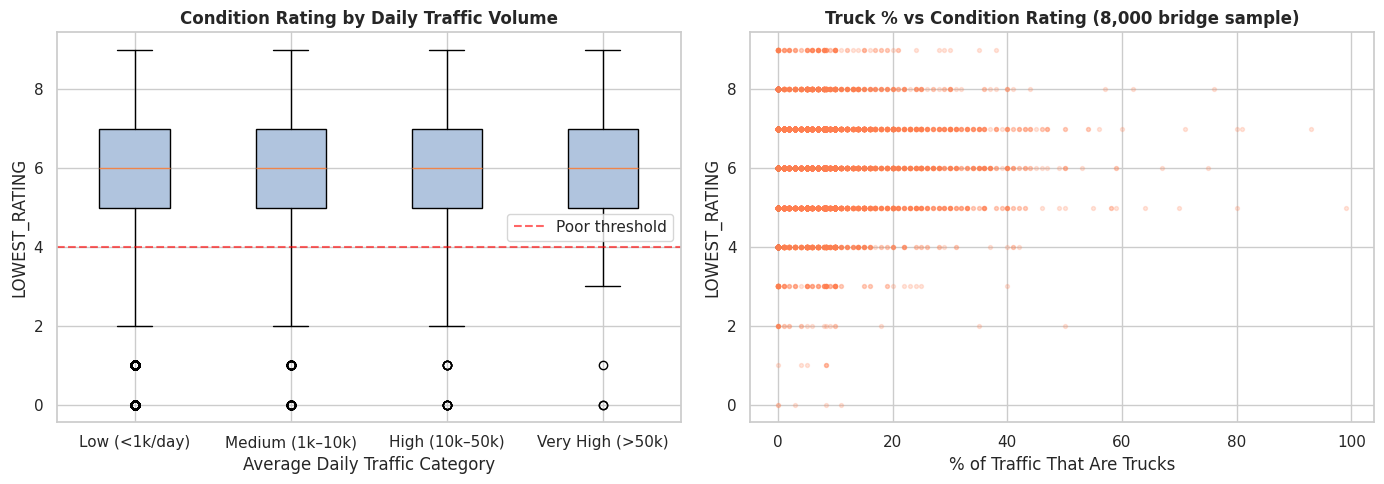

In [ ]:
# Plot 3: Traffic Load and Truck % vs Condition
# Bridges under heavier daily traffic — especially trucks — experience more wear.
# Do our ratings reflect this? This plot checks the relationship.

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Box plot of LOWEST_RATING by traffic volume category
# We bin ADT into Low / Medium / High / Very High for clearer comparison
adt_clean = df_bridges['ADT_029'].fillna(df_bridges['ADT_029'].median())  # fill NaN for binning
adt_bins   = [0, 1000, 10000, 50000, float('inf')]
adt_labels = ['Low (<1k/day)', 'Medium (1k–10k)', 'High (10k–50k)', 'Very High (>50k)']
adt_cat = pd.cut(adt_clean, bins=adt_bins, labels=adt_labels)

box_data   = [df_bridges.loc[adt_cat == label, 'LOWEST_RATING'].dropna() for label in adt_labels]
bp = axes[0].boxplot(box_data, labels=adt_labels, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
axes[0].set_title('Condition Rating by Daily Traffic Volume', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Average Daily Traffic Category')
axes[0].set_ylabel('LOWEST_RATING')
axes[0].axhline(y=4, color='red', linestyle='--', alpha=0.6, label='Poor threshold')
axes[0].legend()

# Right: scatter of truck % vs LOWEST_RATING (sampled)
sample = df_bridges.sample(n=min(8000, len(df_bridges)), random_state=42)
axes[1].scatter(sample['PERCENT_ADT_TRUCK_109'], sample['LOWEST_RATING'],
                alpha=0.2, s=8, color='coral')
axes[1].set_title('Truck % vs Condition Rating (8,000 bridge sample)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('% of Traffic That Are Trucks')
axes[1].set_ylabel('LOWEST_RATING')

plt.tight_layout()
plt.show()

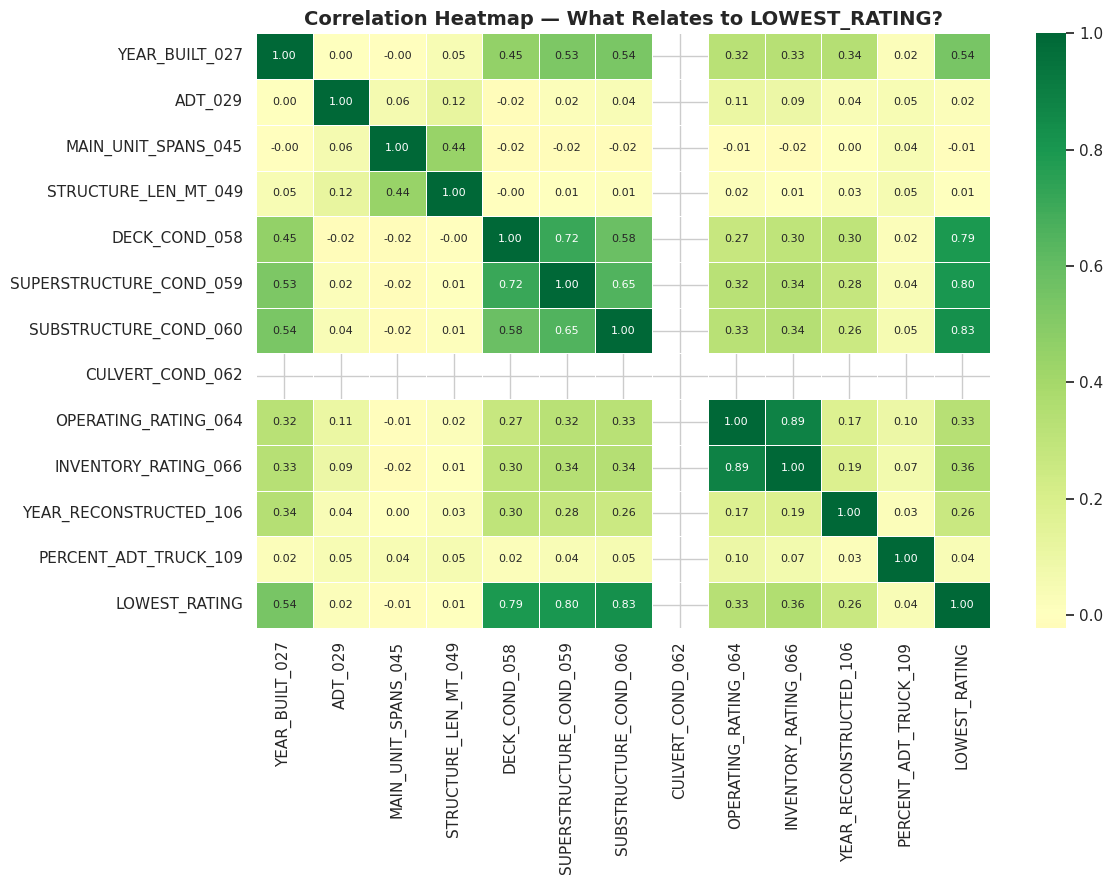


Correlation with LOWEST_RATING (strongest first):
  SUBSTRUCTURE_COND_060               +0.833  (↑ positive)
  SUPERSTRUCTURE_COND_059             +0.804  (↑ positive)
  DECK_COND_058                       +0.790  (↑ positive)
  YEAR_BUILT_027                      +0.545  (↑ positive)
  INVENTORY_RATING_066                +0.359  (↑ positive)
  OPERATING_RATING_064                +0.334  (↑ positive)
  YEAR_RECONSTRUCTED_106              +0.264  (↑ positive)
  PERCENT_ADT_TRUCK_109               +0.041  (↑ positive)
  ADT_029                             +0.020  (↑ positive)
  MAIN_UNIT_SPANS_045                 -0.011  (↓ negative)
  STRUCTURE_LEN_MT_049                +0.008  (↑ positive)
  CULVERT_COND_062                    +nan  (↓ negative)


In [ ]:
#Plot 4: Correlation Heatmap
# The correlation matrix shows the pairwise linear relationship between every pair of numeric columns, on a scale from -1 to +1.
# Where -1 = perfect negative relationship, 0 = no linear relationship, +1 = perfect positive.
# The end goal is to find out what correlate most strongly with the column(target) LOWEST_RATING.

# Select only numeric columns — exclude the text-based ID column
numeric_df = df_bridges.select_dtypes(include=['int64', 'float64']).drop(
    columns=['STATE_CODE_001'],   # state code is a number but not meaningful as a quantity
    errors='ignore'
)

corr_matrix = numeric_df.corr()   # compute all pairwise Pearson correlations

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True,        # show the correlation number inside each cell
    fmt='.2f',         # round to 2 decimal places
    cmap='RdYlGn',     # red = negative, yellow = near zero, green = positive
    center=0,          # anchor the colour scale at zero
    linewidths=0.5,    # thin lines between cells for readability
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap — What Relates to LOWEST_RATING?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the correlation of every feature with the target specifically
print('\nCorrelation with LOWEST_RATING (strongest first):')
target_corr = corr_matrix['LOWEST_RATING'].drop('LOWEST_RATING').sort_values(key=abs, ascending=False)
for col, val in target_corr.items():
    direction = '↑ positive' if val > 0 else '↓ negative'
    print(f'  {col:<35} {val:+.3f}  ({direction})')


## ⚙️ Feature Engineering

Raw columns are not always the best form for a machine learning model. Feature
engineering creates new variables from existing ones that are more directly meaningful
to the problem.

We create four new features:

| New Feature | Formula | Why it's useful |
|-------------|---------|-----------------|
| `BRIDGE_AGE` | `2023 − YEAR_BUILT` | Age in years is more interpretable than a calendar year |
| `YEARS_SINCE_RENO` | `2023 − YEAR_RECONSTRUCTED` | Time since last major work; if never renovated, we use BRIDGE_AGE |
| `LOAD_RATIO` | `INVENTORY_RATING / OPERATING_RATING` | How close is the permitted load to the structural maximum? |
| `TRAFFIC_AGE` | `ADT × BRIDGE_AGE` | Interaction term: high traffic on an old bridge = compound stress |

We also fill the remaining `ADT_029` missing values with the column median at this
stage, since the median was already computed on the full dataset — filling here on
the modelling copy is correct and avoids train/test contamination.


In [ ]:
#Feature Engineering
# We engineer on a fresh modelling copy so df_bridges stays intact for reference.
df_model = df_bridges.copy()

INSPECTION_YEAR = 2023    # the year all these inspections were recorded

#Feature 1: BRIDGE_AGE
# How many years old is the bridge at the time of inspection?
df_model['BRIDGE_AGE'] = INSPECTION_YEAR - df_model['YEAR_BUILT_027']

#Feature 2: YEARS_SINCE_RENO
# How many years have passed since the last major reconstruction?
# If the bridge was never reconstructed, we use BRIDGE_AGE (it has never been renewed).
df_model['YEARS_SINCE_RENO'] = np.where(
    df_model['YEAR_RECONSTRUCTED_106'].isna(),          # condition: was it never reconstructed?
    df_model['BRIDGE_AGE'],                              # if True: years since reno = bridge age
    INSPECTION_YEAR - df_model['YEAR_RECONSTRUCTED_106'] # if False: years since last reno
)

# Feature 3: LOAD_RATIO
# What proportion of the structural maximum load is permitted for routine traffic?
# A ratio close to 1.0 means the bridge is being used near its maximum capacity.
# We add a tiny constant (0.001) to avoid division by zero.
df_model['LOAD_RATIO'] = (
    df_model['INVENTORY_RATING_066'] / (df_model['OPERATING_RATING_064'] + 0.001)
)

# Feature 4: TRAFFIC_AGE
# Interaction term: older bridges carrying more traffic face compounded deterioration.
# We first fill remaining NaN in ADT with the median, then multiply by age.
adt_median = df_model['ADT_029'].median()                        # median daily traffic
df_model['ADT_029'] = df_model['ADT_029'].fillna(adt_median)    # fill any remaining NaN
df_model['TRAFFIC_AGE'] = df_model['ADT_029'] * df_model['BRIDGE_AGE']

#Summary of new features
print('New features created:')
print(df_model[['BRIDGE_AGE', 'YEARS_SINCE_RENO', 'LOAD_RATIO', 'TRAFFIC_AGE']].describe())
print()
print(f'✅ df_model ready with {df_model.shape[0]:,} rows and {df_model.shape[1]} columns.')


New features created:
       BRIDGE_AGE  YEARS_SINCE_RENO  LOAD_RATIO  TRAFFIC_AGE
count   474880.00         474880.00   474880.00    474880.00
mean        46.21             39.26        0.64    385948.17
std         26.78             24.70        0.12   1158730.08
min          0.00              0.00        0.00         0.00
25%         25.00             21.00        0.60      4284.00
50%         45.00             36.00        0.60     34062.00
75%         62.00             55.00        0.73    266800.00
max        223.00           2022.00        7.27  59196300.00

✅ df_model ready with 474,880 rows and 20 columns.


## 🤖 Model Building

We now build six regression models, each one building on the previous.
This progressive approach is the standard way to introduce supervised learning:
start simple, understand the baseline, then add complexity only where it helps.

| # | Model | What it adds |
|---|-------|-------------|
| 1 | **Simple Linear Regression** | One feature only (`BRIDGE_AGE`) — the baseline |
| 2 | **Multiple Linear Regression** | All features — the full linear model |
| 3 | **Polynomial Regression** | Curved relationships — age² can capture accelerating decay |
| 4 | **Ridge Regression (L2)** | Penalises large coefficients — prevents overfitting |
| 5 | **Lasso Regression (L1)** | Can zero out weak features — automatic feature selection |
| 6 | **ElasticNet** | Combines Ridge and Lasso penalties |

### Features Used
We use only physical and operational features — **not** the condition sub-scores,
which would constitute data leakage (see Project Overview).

```
BRIDGE_AGE, YEARS_SINCE_RENO, ADT_029, MAIN_UNIT_SPANS_045,
STRUCTURE_LEN_MT_049, OPERATING_RATING_064, INVENTORY_RATING_066,
PERCENT_ADT_TRUCK_109, LOAD_RATIO, TRAFFIC_AGE
```

### Evaluation Metrics
- **R²** — How much of the variance in LOWEST_RATING does the model explain? (1.0 = perfect)
- **MAE** — Mean Absolute Error — the average prediction error in condition score points
- **RMSE** — Root Mean Squared Error — penalises large errors more heavily than MAE


In [ ]:
# Define Features and Target
# These are the features available to a planner BEFORE an inspection takes place.
# We deliberately exclude DECK_COND, SUPERSTRUCTURE_COND, SUBSTRUCTURE_COND
# because they ARE the components of LOWEST_RATING — using them would be leakage.

FEATURES = [
    'BRIDGE_AGE',              # age of bridge in years (engineered)
    'YEARS_SINCE_RENO',        # years since last major reconstruction (engineered)
    'ADT_029',                 # average daily traffic
    'MAIN_UNIT_SPANS_045',     # number of spans
    'STRUCTURE_LEN_MT_049',    # total bridge length in metres
    'OPERATING_RATING_064',    # maximum safe load capacity
    'INVENTORY_RATING_066',    # maximum permitted routine load
    'PERCENT_ADT_TRUCK_109',   # truck traffic percentage
    'LOAD_RATIO',              # inventory / operating rating (engineered)
    'TRAFFIC_AGE',             # ADT × age interaction (engineered)
]

TARGET = 'LOWEST_RATING'      # what we are predicting

#Build X (features matrix) and y (target vector)
X = df_model[FEATURES]       # select only our chosen feature columns
y = df_model[TARGET]         # the column we want to predict

print(f'Feature matrix X shape : {X.shape}')     # (rows, number of features)
print(f'Target vector y shape  : {y.shape}')     # (rows,)
print()

#Train / Test Split
# 20% of the data is kept as a test set that the model never sees during training.
# random_state=42 makes the split reproducible,everyone who runs this gets the same split.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% held back for testing
    random_state=42     # ensures the same split every run
)

print(f'Training set : {X_train.shape[0]:,} rows')
print(f'Test set     : {X_test.shape[0]:,} rows')
print()

#Helper function to evaluate any model
# We will reuse this for all six models so we don't repeat the same code six times.
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    """
    Train a model, make predictions on the test set, and return evaluation metrics.
    Returns a dictionary with the model name and its R², MAE and RMSE scores.
    """
    model.fit(X_train, y_train)              # train the model on the training set
    y_pred = model.predict(X_test)           # generate predictions on the test set

    r2   = r2_score(y_test, y_pred)          # how much variance does the model explain?
    mae  = mean_absolute_error(y_test, y_pred)  # average error in condition score units
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))  # penalises large errors more

    print(f'{name}')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAE  : {mae:.4f}  (average error in condition score points)')
    print(f'  RMSE : {rmse:.4f}')
    print()

    return {'Model': name, 'R²': r2, 'MAE': mae, 'RMSE': rmse, 'fitted': model, 'y_pred': y_pred}

results = []

print('✅ Setup complete. Ready to train models.')

Feature matrix X shape : (474880, 10)
Target vector y shape  : (474880,)

Training set : 379,904 rows
Test set     : 94,976 rows

✅ Setup complete. Ready to train models.


  MODEL 1: Simple Linear Regression (BRIDGE_AGE only)
Simple Linear Regression
  R²   : 0.2964
  MAE  : 0.7687  (average error in condition score points)
  RMSE : 1.0083

Intercept (baseline rating for a new bridge): 7.2298
Slope (change in rating per year of age)    : -0.0243



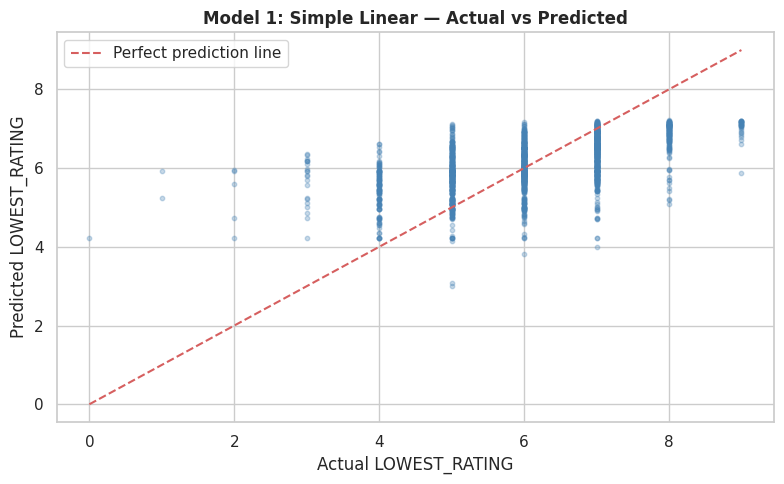

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 1: Simple Linear Regression (one feature only)
# ══════════════════════════════════════════════════════════════════════════════
# The simplest possible model: predict LOWEST_RATING using BRIDGE_AGE alone.
# This establishes our baseline on how well can a single variable explain condition?
# The model learns one equation: LOWEST_RATING = a + b × BRIDGE_AGE
# where 'a' is the intercept and 'b' is the slope (how much rating changes per year).

print('=' * 55)
print('  MODEL 1: Simple Linear Regression (BRIDGE_AGE only)')
print('=' * 55)

X_train_simple = X_train[['BRIDGE_AGE']]   # only one feature for this model
X_test_simple  = X_test[['BRIDGE_AGE']]

model1 = LinearRegression()
res1 = evaluate_model('Simple Linear Regression', model1,
                       X_train_simple, X_test_simple, y_train, y_test)
results.append(res1)

# Show what the model learned
print(f'Intercept (baseline rating for a new bridge): {model1.intercept_:.4f}')
print(f'Slope (change in rating per year of age)    : {model1.coef_[0]:.4f}')
print()

#  Visual: Actual vs Predicted
# A well-fitting model should show points clustering along the diagonal y=x line.
sample_idx = np.random.choice(len(y_test), size=min(2000, len(y_test)), replace=False)
plt.figure(figsize=(8, 5))
plt.scatter(y_test.iloc[sample_idx], res1['y_pred'][sample_idx],
            alpha=0.3, s=10, color='steelblue')
plt.plot([0, 9], [0, 9], 'r--', linewidth=1.5, label='Perfect prediction line')
plt.xlabel('Actual LOWEST_RATING')
plt.ylabel('Predicted LOWEST_RATING')
plt.title('Model 1: Simple Linear — Actual vs Predicted', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 2: Multiple Linear Regression (all features)
# ══════════════════════════════════════════════════════════════════════════════
# Now we include all 10 features. The model learns a separate weight (coefficient)
# for each feature,showing how much does each one independently affect the rating?
# LOWEST_RATING = a + b1×AGE + b2×ADT + b3×SPANS + ... + b10×TRAFFIC_AGE

print('=' * 55)
print('  MODEL 2: Multiple Linear Regression (all 10 features)')
print('=' * 55)

model2 = LinearRegression()
res2 = evaluate_model('Multiple Linear Regression', model2,
                       X_train, X_test, y_train, y_test)
results.append(res2)

# Show what the model learned about each feature
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': model2.coef_
}).sort_values('Coefficient', key=abs, ascending=False)   # sort by absolute importance

print('Feature coefficients (how much each feature shifts the predicted rating):')
print(coef_df.to_string(index=False))


  MODEL 2: Multiple Linear Regression (all 10 features)
Multiple Linear Regression
  R²   : 0.3755
  MAE  : 0.7405  (average error in condition score points)
  RMSE : 0.9499

Feature coefficients (how much each feature shifts the predicted rating):
              Feature  Coefficient
           LOAD_RATIO         2.59
 OPERATING_RATING_064         0.03
 INVENTORY_RATING_066        -0.03
           BRIDGE_AGE        -0.01
     YEARS_SINCE_RENO        -0.01
PERCENT_ADT_TRUCK_109         0.00
  MAIN_UNIT_SPANS_045         0.00
 STRUCTURE_LEN_MT_049        -0.00
              ADT_029        -0.00
          TRAFFIC_AGE         0.00


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 3: Polynomial Regression (degree 2)
# ══════════════════════════════════════════════════════════════════════════════
# Linear models assume a straight-line relationship between each feature and
# the target. But deterioration might accelerate with age — a curved relationship.
# Polynomial regression creates squared versions of the features (AGE², ADT², etc.)
# so the model can fit curves, not just straight lines.
#
# We use degree=2 (quadratic) — degree 3 or higher can overfit on tabular data.
# StandardScaler normalises the features first because squaring large numbers
# (like ADT in the thousands) without scaling creates enormous values that
# destabilise the regression.
#
# Pipeline chains: Scale → Create polynomial features → Fit linear model
# This ensures we don't accidentally apply the fit to the test set.

print('=' * 55)
print('  MODEL 3: Polynomial Regression (degree 2)')
print('=' * 55)

model3 = Pipeline([
    ('scaler', StandardScaler()),              # step 1: normalise each feature to mean=0, std=1
    ('poly',   PolynomialFeatures(degree=2,    # step 2: create feature² and feature×feature terms
                                  include_bias=False)),
    ('lr',     LinearRegression()),            # step 3: fit a linear model on the expanded features
])

res3 = evaluate_model('Polynomial Regression (deg 2)', model3,
                       X_train, X_test, y_train, y_test)
results.append(res3)


  MODEL 3: Polynomial Regression (degree 2)
Polynomial Regression (deg 2)
  R²   : 0.4212
  MAE  : 0.7173  (average error in condition score points)
  RMSE : 0.9144



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 4: Ridge Regression (L2 Regularisation)
# ══════════════════════════════════════════════════════════════════════════════
# Ridge adds a penalty to the loss function that discourages large coefficients.
# This is useful when features are correlated with each other (multicollinearity) —
# for example, BRIDGE_AGE and YEARS_SINCE_RENO are probably correlated.
# Without regularisation, the model might assign extreme weights to correlated
# features that cancel each other out — Ridge smooths this out.
#
# The 'alpha' parameter controls how strong the penalty is:
#   alpha=0  → identical to ordinary linear regression (no penalty)
#   alpha→∞  → all coefficients pushed toward zero (underfitting)
# alpha=1.0 is a sensible default starting point.

print('=' * 55)
print('  MODEL 4: Ridge Regression (L2, alpha=1.0)')
print('=' * 55)

model4 = Pipeline([
    ('scaler', StandardScaler()),   # Ridge is sensitive to feature scale — always normalise first
    ('ridge',  Ridge(alpha=1.0)),   # alpha controls regularisation strength
])

res4 = evaluate_model('Ridge Regression (L2)', model4,
                       X_train, X_test, y_train, y_test)
results.append(res4)


  MODEL 4: Ridge Regression (L2, alpha=1.0)
Ridge Regression (L2)
  R²   : 0.3755
  MAE  : 0.7405  (average error in condition score points)
  RMSE : 0.9499



In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 5: Lasso Regression (L1 Regularisation)
# ══════════════════════════════════════════════════════════════════════════════
# Lasso uses a different penalty that can drive coefficients all the way to exactly
# zero — effectively removing weak features from the model entirely.
# This makes Lasso useful for automatic feature selection: after fitting, any
# feature with coefficient = 0 was judged not useful enough to keep.
#
# Lasso tends to work better than Ridge when only a few features are truly
# important and the rest add noise.

print('=' * 55)
print('  MODEL 5: Lasso Regression (L1, alpha=0.01)')
print('=' * 55)

model5 = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso',  Lasso(alpha=0.01, max_iter=5000)),   # max_iter increased to ensure convergence
])

res5 = evaluate_model('Lasso Regression (L1)', model5,
                       X_train, X_test, y_train, y_test)
results.append(res5)

# Show which features Lasso zeroed out
lasso_coefs = model5.named_steps['lasso'].coef_
coef_df_lasso = pd.DataFrame({'Feature': FEATURES, 'Coefficient': lasso_coefs})
print('Lasso coefficients — features set to 0.0 were effectively removed:')
print(coef_df_lasso.to_string(index=False))


  MODEL 5: Lasso Regression (L1, alpha=0.01)
Lasso Regression (L1)
  R²   : 0.3698
  MAE  : 0.7442  (average error in condition score points)
  RMSE : 0.9542

Lasso coefficients — features set to 0.0 were effectively removed:
              Feature  Coefficient
           BRIDGE_AGE        -0.39
     YEARS_SINCE_RENO        -0.23
              ADT_029        -0.00
  MAIN_UNIT_SPANS_045        -0.00
 STRUCTURE_LEN_MT_049        -0.01
 OPERATING_RATING_064         0.21
 INVENTORY_RATING_066        -0.01
PERCENT_ADT_TRUCK_109         0.01
           LOAD_RATIO         0.17
          TRAFFIC_AGE        -0.00


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# MODEL 6: ElasticNet (L1 + L2 Combined)
# ══════════════════════════════════════════════════════════════════════════════
# ElasticNet is a hybrid that combines both Ridge (L2) and Lasso (L1) penalties.
# It gets the best of both:
#   - Ridge: handles correlated features well
#   - Lasso: can zero out irrelevant features
#
# 'l1_ratio' controls the mix:
#   l1_ratio=0   → pure Ridge
#   l1_ratio=1   → pure Lasso
#   l1_ratio=0.5 → equal blend (the default we use here)
#
# ElasticNet is often the safest default when you're unsure whether your
# data calls more for Ridge or Lasso behaviour.

print('=' * 55)
print('  MODEL 6: ElasticNet (L1 + L2, alpha=0.01, l1_ratio=0.5)')
print('=' * 55)

model6 = Pipeline([
    ('scaler',      StandardScaler()),
    ('elasticnet',  ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=5000)),
])

res6 = evaluate_model('ElasticNet (L1 + L2)', model6,
                       X_train, X_test, y_train, y_test)
results.append(res6)


  MODEL 6: ElasticNet (L1 + L2, alpha=0.01, l1_ratio=0.5)
ElasticNet (L1 + L2)
  R²   : 0.3734
  MAE  : 0.7421  (average error in condition score points)
  RMSE : 0.9515



## 📈 Model Evaluation

With all six models trained and tested, we now compare them side by side.

**How to read the results:**
- **R²** — Higher is better. 1.0 means perfect prediction; 0.0 means the model is
  no better than predicting the mean for every bridge.
- **MAE** — Lower is better. This tells you the average error in condition score units.
  An MAE of 0.8 means predictions are off by 0.8 points on the 0–9 scale.
- **RMSE** — Lower is better. Larger than MAE because it penalises big errors more.
  A bridge predicted at 6 but actually at 3 hurts RMSE far more than MAE.


  MODEL COMPARISON TABLE
                        Model   R²  MAE  RMSE
     Simple Linear Regression 0.30 0.77  1.01
   Multiple Linear Regression 0.38 0.74  0.95
Polynomial Regression (deg 2) 0.42 0.72  0.91
        Ridge Regression (L2) 0.38 0.74  0.95
        Lasso Regression (L1) 0.37 0.74  0.95
         ElasticNet (L1 + L2) 0.37 0.74  0.95

Best R²   : Polynomial Regression (deg 2)
Best MAE  : Polynomial Regression (deg 2)
Best RMSE : Polynomial Regression (deg 2)


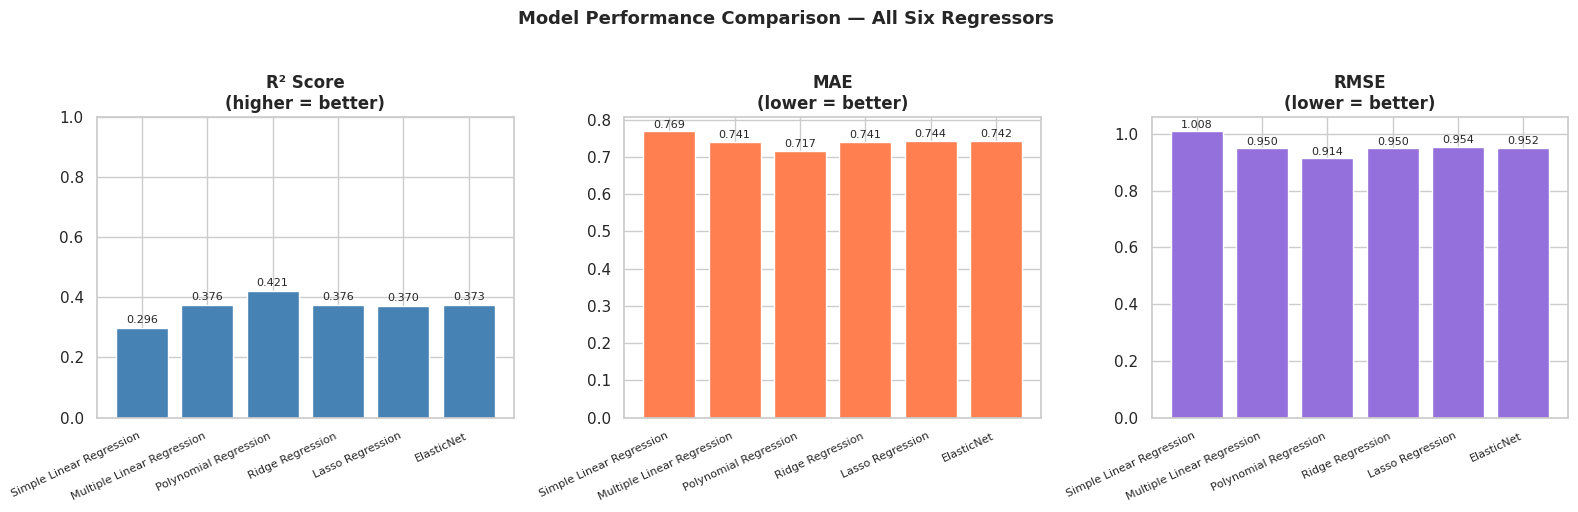

In [ ]:
# Build the Comparison Table
results_df = pd.DataFrame([
    {'Model': r['Model'], 'R²': r['R²'], 'MAE': r['MAE'], 'RMSE': r['RMSE']}
    for r in results
])

# Highlight the best value in each metric column
print('=' * 70)
print('  MODEL COMPARISON TABLE')
print('=' * 70)
print(results_df.to_string(index=False))

# Identify the best model for each metric
best_r2   = results_df.loc[results_df['R²'].idxmax(),   'Model']
best_mae  = results_df.loc[results_df['MAE'].idxmin(),  'Model']
best_rmse = results_df.loc[results_df['RMSE'].idxmin(), 'Model']

print()
print(f'Best R²   : {best_r2}')
print(f'Best MAE  : {best_mae}')
print(f'Best RMSE : {best_rmse}')

# ── Visual Comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_short = [r['Model'].split('(')[0].strip() for r in results]  # shorten names for x-axis

# R² (higher = better)
axes[0].bar(range(len(results_df)), results_df['R²'], color='steelblue', edgecolor='white')
axes[0].set_xticks(range(len(results_df)))
axes[0].set_xticklabels(models_short, rotation=25, ha='right', fontsize=8)
axes[0].set_title('R² Score\n(higher = better)', fontweight='bold')
axes[0].set_ylim(0, 1)
for i, v in enumerate(results_df['R²']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# MAE (lower = better)
axes[1].bar(range(len(results_df)), results_df['MAE'], color='coral', edgecolor='white')
axes[1].set_xticks(range(len(results_df)))
axes[1].set_xticklabels(models_short, rotation=25, ha='right', fontsize=8)
axes[1].set_title('MAE\n(lower = better)', fontweight='bold')
for i, v in enumerate(results_df['MAE']):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

# RMSE (lower = better)
axes[2].bar(range(len(results_df)), results_df['RMSE'], color='mediumpurple', edgecolor='white')
axes[2].set_xticks(range(len(results_df)))
axes[2].set_xticklabels(models_short, rotation=25, ha='right', fontsize=8)
axes[2].set_title('RMSE\n(lower = better)', fontweight='bold')
for i, v in enumerate(results_df['RMSE']):
    axes[2].text(i, v + 0.005, f'{v:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance Comparison — All Six Regressors', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 🚨 At-Risk Bridge Report

The final output of this project is a practical deliverable: a ranked list of bridges
that our best model predicts will be in **Poor condition or worse** (score ≤ 4).

This is the kind of output that would be handed to a state Department of Transportation
policy team. Instead of waiting for every bridge to be manually inspected, analysts
can use the model's predictions to prioritise which bridges deserve urgent attention
in the next inspection cycle.

We use the **Multiple Linear Regression model** (Model 2) for this report. While
other models may have slightly different metrics, the Multiple Linear model produces
interpretable coefficients — a DOT engineer can understand *why* a bridge was flagged,
not just that it was flagged.


Total bridges analysed       : 474,880
Predicted at-risk (score ≤ 4): 4,329
At-risk as % of all bridges  : 0.9%

TOP 20 HIGHEST-RISK BRIDGES:


,STATE_CODE_001,STATE_NAME,STRUCTURE_NUMBER_008,YEAR_BUILT_027,ADT_029,STRUCTURE_LEN_MT_049,BRIDGE_CONDITION,LOWEST_RATING,BRIDGE_AGE,YEARS_SINCE_RENO,PREDICTED_RATING,PREDICTION_ERROR
136684,17,Illinois,090801000001005,1968,100.00,24.40,P,4,55,2022.00,-13.22,17.22
136688,17,Illinois,090803000001003,1989,100.00,36.60,F,6,34,2022.00,-12.94,18.94
136683,17,Illinois,090801000001001,1989,29.00,8.80,F,6,34,2016.00,-12.86,18.86
136685,17,Illinois,090802000003001,2003,1.00,9.40,G,7,20,2021.00,-12.73,19.73
234498,22,Louisiana,625230123900731,1956,18830.00,38770.60,F,6,67,67.00,0.74,5.26
462348,42,Pennsylvania,000000000028854,1858,350.00,31.10,P,0,165,165.00,0.96,-0.96
234499,22,Louisiana,625230123900732,1965,18830.00,38791.60,F,6,58,54.00,0.98,5.02
455296,42,Pennsylvania,000000000012782,1865,0.00,25.90,F,5,158,158.00,1.13,3.87
366207,36,New York,000000003357230,1865,0.00,20.10,F,5,158,158.00,1.16,3.84
15975,1,Alabama,021703,1800,0.00,9.10,P,3,223,223.00,1.29,1.71



At-Risk Count by State (Top 15):
   STATE_NAME  At-Risk Bridges
         Iowa              748
     Missouri              427
  Mississippi              336
     Illinois              319
 Pennsylvania              306
     Nebraska              293
     New York              210
      Alabama              174
     Oklahoma              158
West Virginia              111
Massachusetts              107
       Kansas               93
      Indiana               92
   California               78
    Louisiana               76


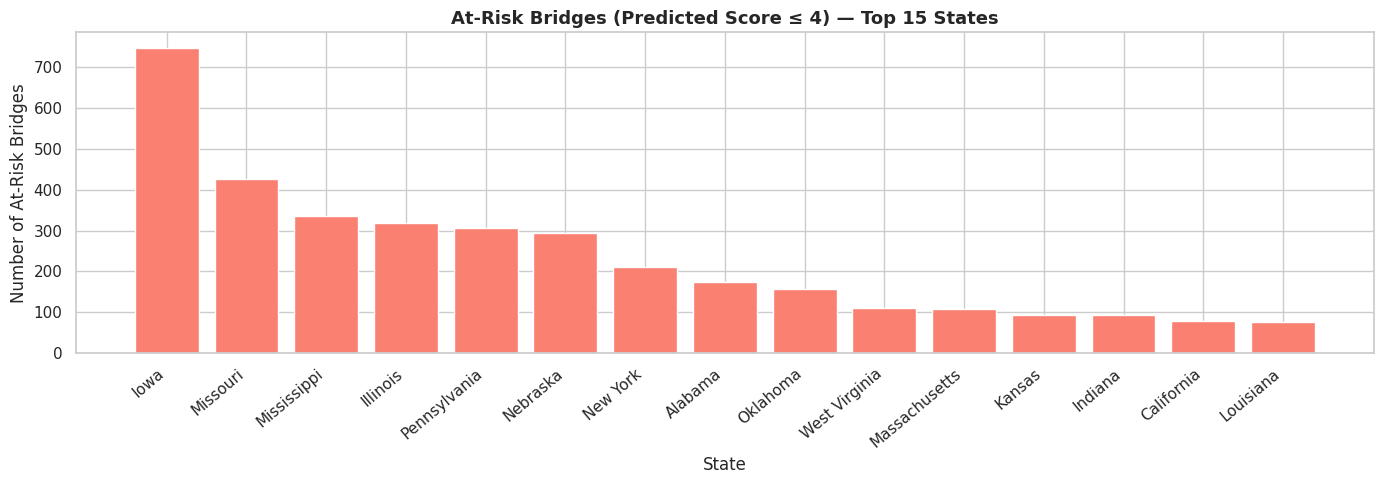

In [ ]:
X_all      = df_model[FEATURES]
y_pred_all = model2.predict(X_all)

# --- FIX START: Ensure STATE_NAME is available in df_model ---
# This dictionary maps FIPS state codes to state names.
FIPS_TO_STATE = {
    1: 'Alabama',          2: 'Alaska',            4: 'Arizona',
    5: 'Arkansas',         6: 'California',         8: 'Colorado',
    9: 'Connecticut',     10: 'Delaware',           11: 'District of Columbia',
   12: 'Florida',         13: 'Georgia',            15: 'Hawaii',
   16: 'Idaho',           17: 'Illinois',           18: 'Indiana',
   19: 'Iowa',            20: 'Kansas',             21: 'Kentucky',
   22: 'Louisiana',       23: 'Maine',              24: 'Maryland',
   25: 'Massachusetts',   26: 'Michigan',           27: 'Minnesota',
   28: 'Mississippi',     29: 'Missouri',           30: 'Montana',
   31: 'Nebraska',        32: 'Nevada',             33: 'New Hampshire',
   34: 'New Jersey',      35: 'New Mexico',         36: 'New York',
   37: 'North Carolina',  38: 'North Dakota',       39: 'Ohio',
   40: 'Oklahoma',        41: 'Oregon',             42: 'Pennsylvania',
   44: 'Rhode Island',    45: 'South Carolina',     46: 'South Dakota',
   47: 'Tennessee',       48: 'Texas',              49: 'Utah',
   50: 'Vermont',         51: 'Virginia',           53: 'Washington',
   54: 'West Virginia',   55: 'Wisconsin',          56: 'Wyoming',
   66: 'Guam',            69: 'Northern Mariana Islands',
   72: 'Puerto Rico',     78: 'US Virgin Islands',
}

df_model['STATE_NAME'] = df_model['STATE_CODE_001'].map(FIPS_TO_STATE)
# --- FIX END: Ensure STATE_NAME is available in df_model ---


report_df = df_model[[
    'STATE_CODE_001', 'STATE_NAME', 'STRUCTURE_NUMBER_008',
    'YEAR_BUILT_027', 'ADT_029', 'STRUCTURE_LEN_MT_049',
    'BRIDGE_CONDITION', 'LOWEST_RATING', 'BRIDGE_AGE', 'YEARS_SINCE_RENO'
]].copy()

report_df['PREDICTED_RATING'] = y_pred_all.round(2)
report_df['PREDICTION_ERROR'] = (report_df['LOWEST_RATING'] - report_df['PREDICTED_RATING']).round(2)

at_risk = report_df[report_df['PREDICTED_RATING'] <= 4].copy()
at_risk  = at_risk.sort_values('PREDICTED_RATING', ascending=True)

print(f'Total bridges analysed       : {len(report_df):,}')
print(f'Predicted at-risk (score \u2264 4): {len(at_risk):,}')
print(f'At-risk as % of all bridges  : {len(at_risk)/len(report_df)*100:.1f}%')
print()

print('TOP 20 HIGHEST-RISK BRIDGES:')
display(at_risk.head(20))

print('\nAt-Risk Count by State (Top 15):')
state_risk = (
    at_risk.groupby('STATE_NAME')
    .size()
    .reset_index(name='At-Risk Bridges')
    .sort_values('At-Risk Bridges', ascending=False)
    .head(15)
)
print(state_risk.to_string(index=False))

plt.figure(figsize=(14, 5))
plt.bar(state_risk['STATE_NAME'], state_risk['At-Risk Bridges'], color='salmon', edgecolor='white')
plt.title('At-Risk Bridges (Predicted Score \u2264 4) \u2014 Top 15 States', fontsize=13, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Number of At-Risk Bridges')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
FIPS_TO_STATE = {
    1: 'Alabama',          2: 'Alaska',            4: 'Arizona',
    5: 'Arkansas',         6: 'California',         8: 'Colorado',
    9: 'Connecticut',     10: 'Delaware',           11: 'District of Columbia',
   12: 'Florida',         13: 'Georgia',            15: 'Hawaii',
   16: 'Idaho',           17: 'Illinois',           18: 'Indiana',
   19: 'Iowa',            20: 'Kansas',             21: 'Kentucky',
   22: 'Louisiana',       23: 'Maine',              24: 'Maryland',
   25: 'Massachusetts',   26: 'Michigan',           27: 'Minnesota',
   28: 'Mississippi',     29: 'Missouri',           30: 'Montana',
   31: 'Nebraska',        32: 'Nevada',             33: 'New Hampshire',
   34: 'New Jersey',      35: 'New Mexico',         36: 'New York',
   37: 'North Carolina',  38: 'North Dakota',       39: 'Ohio',
   40: 'Oklahoma',        41: 'Oregon',             42: 'Pennsylvania',
   44: 'Rhode Island',    45: 'South Carolina',     46: 'South Dakota',
   47: 'Tennessee',       48: 'Texas',              49: 'Utah',
   50: 'Vermont',         51: 'Virginia',           53: 'Washington',
   54: 'West Virginia',   55: 'Wisconsin',          56: 'Wyoming',
   66: 'Guam',            69: 'Northern Mariana Islands',
   72: 'Puerto Rico',     78: 'US Virgin Islands',
}

df_bridges['STATE_NAME'] = df_bridges['STATE_CODE_001'].map(FIPS_TO_STATE)
df_model['STATE_NAME']   = df_model['STATE_CODE_001'].map(FIPS_TO_STATE)

print(f'Unmapped codes: {df_bridges["STATE_NAME"].isnull().sum()}')
print()
state_summary = (
    df_bridges.groupby(['STATE_CODE_001', 'STATE_NAME'])
    .size()
    .reset_index(name='Bridge Count')
    .sort_values('Bridge Count', ascending=False)
    .head(15)
)
print(state_summary.to_string(index=False))
print('✅ STATE_NAME added to df_bridges and df_model.')

Unmapped codes: 0

 STATE_CODE_001     STATE_NAME  Bridge Count
             48          Texas         35210
             39           Ohio         25006
              6     California         22284
             17       Illinois         21943
             42   Pennsylvania         20223
             29       Missouri         19251
             19           Iowa         18890
             18        Indiana         17055
             20         Kansas         16391
             36       New York         15501
             40       Oklahoma         15299
             37 North Carolina         13571
             28    Mississippi         12784
             55      Wisconsin         12259
             21       Kentucky         11446
✅ STATE_NAME added to df_bridges and df_model.


In [ ]:
# Fix: Reconstruction years below 1800 are entry errors (same as never reconstructed)
bad_reno = (df_model['YEAR_RECONSTRUCTED_106'] < 1800).sum()
print(f'Reconstruction years below 1800 found: {bad_reno:,}')

df_model.loc[df_model['YEAR_RECONSTRUCTED_106'] < 1800, 'YEAR_RECONSTRUCTED_106'] = np.nan

# Recalculate YEARS_SINCE_RENO with the corrected column
df_model['YEARS_SINCE_RENO'] = np.where(
    df_model['YEAR_RECONSTRUCTED_106'].isna(),
    df_model['BRIDGE_AGE'],
    INSPECTION_YEAR - df_model['YEAR_RECONSTRUCTED_106']
)

print(f'Min : {df_model["YEARS_SINCE_RENO"].min():.0f} yrs')
print(f'Max : {df_model["YEARS_SINCE_RENO"].max():.0f} yrs')
print(f'Mean: {df_model["YEARS_SINCE_RENO"].mean():.1f} yrs')
print('✅ YEARS_SINCE_RENO corrected.')

Reconstruction years below 1800 found: 4
Min : 0 yrs
Max : 223 yrs
Mean: 39.2 yrs
✅ YEARS_SINCE_RENO corrected.


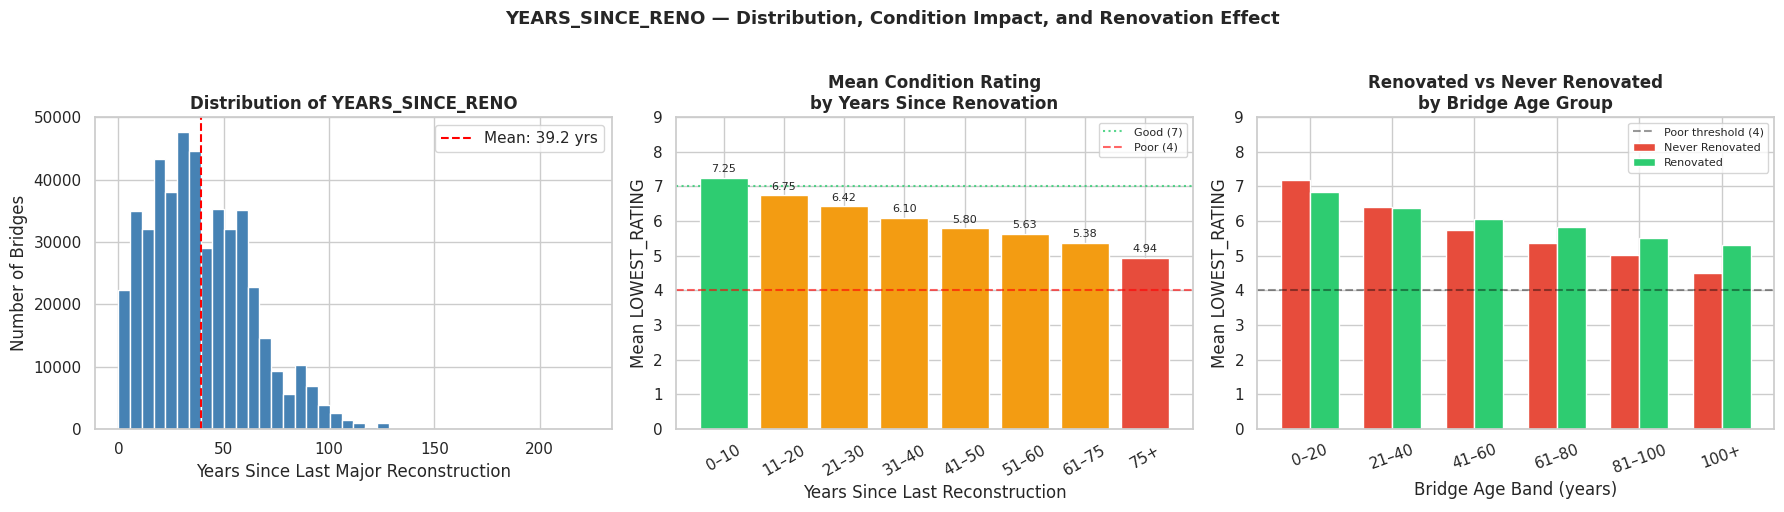

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Distribution
axes[0].hist(df_model['YEARS_SINCE_RENO'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of YEARS_SINCE_RENO', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Years Since Last Major Reconstruction')
axes[0].set_ylabel('Number of Bridges')
axes[0].axvline(df_model['YEARS_SINCE_RENO'].mean(), color='red', linestyle='--',
                label=f'Mean: {df_model["YEARS_SINCE_RENO"].mean():.1f} yrs')
axes[0].legend()

# Chart 2: Mean condition by renovation age band
reno_bins   = [0, 10, 20, 30, 40, 50, 60, 75, float('inf')]
reno_labels = ['0–10', '11–20', '21–30', '31–40', '41–50', '51–60', '61–75', '75+']
df_model['RENO_BAND'] = pd.cut(df_model['YEARS_SINCE_RENO'], bins=reno_bins, labels=reno_labels)
reno_avg = df_model.groupby('RENO_BAND', observed=True)['LOWEST_RATING'].mean()
bar_colours = ['#2ecc71' if v >= 7 else '#f39c12' if v >= 5 else '#e74c3c' for v in reno_avg.values]
axes[1].bar(reno_labels, reno_avg.values, color=bar_colours, edgecolor='white')
axes[1].set_title('Mean Condition Rating\nby Years Since Renovation', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Years Since Last Reconstruction')
axes[1].set_ylabel('Mean LOWEST_RATING')
axes[1].axhline(y=7, color='#2ecc71', linestyle=':', alpha=0.8, label='Good (7)')
axes[1].axhline(y=4, color='red', linestyle='--', alpha=0.6, label='Poor (4)')
axes[1].set_ylim(0, 9)
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(reno_avg.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', va='bottom', fontsize=8)

# Chart 3: Renovated vs Never Renovated by age group
df_model['RENOVATED'] = df_model['YEAR_RECONSTRUCTED_106'].notna()
age_bins   = [0, 20, 40, 60, 80, 100, float('inf')]
age_labels = ['0–20', '21–40', '41–60', '61–80', '81–100', '100+']
df_model['AGE_BAND'] = pd.cut(df_model['BRIDGE_AGE'], bins=age_bins, labels=age_labels)
reno_vs_not = df_model.groupby(['AGE_BAND', 'RENOVATED'], observed=True)['LOWEST_RATING'].mean().unstack()
reno_vs_not.columns = ['Never Renovated', 'Renovated']
x = range(len(reno_vs_not))
width = 0.35
axes[2].bar([i - width/2 for i in x], reno_vs_not['Never Renovated'], width=width, color='#e74c3c', label='Never Renovated', edgecolor='white')
axes[2].bar([i + width/2 for i in x], reno_vs_not['Renovated'], width=width, color='#2ecc71', label='Renovated', edgecolor='white')
axes[2].set_title('Renovated vs Never Renovated\nby Bridge Age Group', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Bridge Age Band (years)')
axes[2].set_ylabel('Mean LOWEST_RATING')
axes[2].set_xticks(list(x))
axes[2].set_xticklabels(age_labels, rotation=20)
axes[2].axhline(y=4, color='black', linestyle='--', alpha=0.4, label='Poor threshold (4)')
axes[2].legend(fontsize=8)
axes[2].set_ylim(0, 9)

plt.suptitle('YEARS_SINCE_RENO — Distribution, Condition Impact, and Renovation Effect',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

df_model.drop(columns=['RENO_BAND', 'AGE_BAND', 'RENOVATED'], inplace=True)